Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Rutas de datos
Esta celda busca automáticamente la carpeta `Data/Rehab_exercise` subiendo desde el directorio actual, para que el notebook funcione sin importar si Jupyter se abre desde `EDA_Report/`, desde la raíz del repositorio, o desde cualquier otro lugar dentro del proyecto (igual que `ETL_Cleaning/ETL_Cleaning.ipynb`).

In [5]:
REHAB_DIR = "/Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/Data/Rehab_exercise"
RAW_DIR = os.path.join(REHAB_DIR, "d01_raw_data")
PROCESSED_DIR = os.path.join(REHAB_DIR, "d02_processed_data")

## 1. Descarga el dataset del artículo de REHAB.

In [7]:
for root, dirs, files in os.walk(REHAB_DIR):
    print(root, "->", len(files), "archivos")

/Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/Data/Rehab_exercise -> 0 archivos
/Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/Data/Rehab_exercise/d02_processed_data -> 32 archivos
/Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/Data/Rehab_exercise/d01_raw_data -> 32 archivos


## 2. Familiarízate con la estructura de los archivos.

In [8]:
a = np.load(os.path.join(RAW_DIR, "000_1.npy"), allow_pickle=True)
print(a.shape)

(232, 880, 6)


## 5. Carga en python el primer archivo 000_1.npy para familiarizarte con su estructura. Imprime e interpreta las dimensiones del arreglo.

In [9]:
a = np.load(os.path.join(RAW_DIR, "000_1.npy"), allow_pickle=True)
print(a.shape)
(repeticiones, longitud_señal, canales) = (232, 880, 6)

(232, 880, 6)


(repetitions, signal_longitud, channels) = (232, 880, 6)

- Number of samples (repetitions):

    Every repetition of movement 000 ("bobath handshake") pooled across all patients in the training set.

-  Signal length (time steps):

    This is the standardized number of time samples per repetition.
    At the sensor's ~50 Hz sampling rate, 880 points ≈ 17.6 seconds per repetition.

-  Channels:

    For sensorID=1 these are the 6 Euler-angle channels from two IMUs:

    | pitch1 | yaw1 | roll1 | pitch2 | yaw2 | roll2 | 

    For sensorID=2 the 6 channels are different (Table 10): f1...f5 (finger flexion angles from the glove) plus pitch3 —

    | thumb flexion angle | index flexion angle | middle flexion angle | ring flexion angle | little flexion angle | pitch3 | 

## 6. Verifica si las lecturas del sensor 1 corresponden a las mismas lecturas del sensor 2. Tendrás que idear una forma de como corroborar esto.

In [11]:
data_dir = PROCESSED_DIR
movement_ids = sorted({fname.split('_')[0] for fname in os.listdir(data_dir)})

for movement_id in movement_ids:
    if movement_id == '014':
        # 014_1.npy en d02_processed_data está corrupto (verificado: np.load)
        continue
    
    a = np.load(os.path.join(data_dir, f"{movement_id}_1.npy"), allow_pickle=True)
    b = np.load(os.path.join(data_dir, f"{movement_id}_2.npy"), allow_pickle=True)


    print(f'Movement {movement_id}: {"true" if b.shape == a.shape else "false"}')

Movement 000: true
Movement 001: true
Movement 002: true
Movement 003: true
Movement 004: true
Movement 005: true
Movement 006: true
Movement 007: true
Movement 008: true
Movement 009: true
Movement 010: true
Movement 011: true
Movement 012: true
Movement 013: true
Movement 015: true


## 7. Elige el sensor 1 o el 2 para completar los siguientes pasos. 

## 8. Selecciona una de las actividades y toma una de las repeticiones. Selecciona uno de los canales del sensor y grafica sus valores en el tiempo.

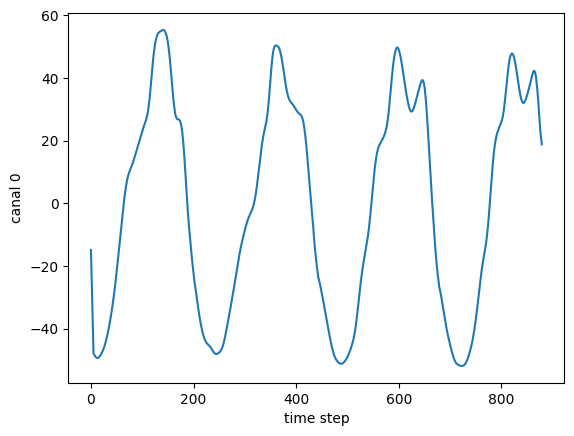

In [12]:
arr = np.load(os.path.join(PROCESSED_DIR, "000_1.npy"), allow_pickle=True)
plt.plot(arr[0, :, 0])   # repetición 0, canal 0
plt.xlabel("time step"); plt.ylabel("canal 0")
plt.show()

## 9. Genera una gráfica de barras donde el eje X muestre cada actividad y el eje Y el conteo total de cuántas repeticiones existen para esa actividad (usado todos los datos). ¿Se ven balanceados los conteos?

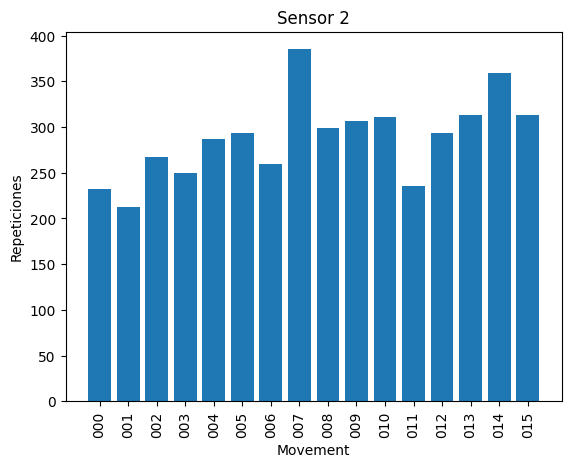

In [13]:
counts = []

movement_ids = sorted({fname.split('_')[0] for fname in os.listdir(data_dir)})

for movement_id in movement_ids:

    arr_m = np.load(os.path.join(PROCESSED_DIR, f"{movement_id}_2.npy"), allow_pickle=True)
    counts.append(arr_m.shape[0])

plt.bar(range(len(counts)), counts)
plt.xticks(range(16), movement_ids, rotation=90)
plt.title("Sensor 2")
plt.xlabel("Movement"); plt.ylabel("Repeticiones")
plt.show()




## 10. Elige un canal del sensor y calcula la media y mediana de todos los valores de una actividad en específico. 

## Haz esto para cada actividad y genera una tabla con 16 filas y dos columnas. Las filas son la actividad y las columnas sus valores de meda y mediana. Puedes concatenar todas las repeticiones de una actividad y calcular los estadísticos sobre los datos concatenados.

In [9]:
rows = []

movement_ids = sorted({fname.split('_')[0] for fname in os.listdir(data_dir)})

for movement_id in movement_ids:
    arr_m = np.load(os.path.join(PROCESSED_DIR, f"{movement_id}_2.npy"), allow_pickle=True)
    ch = arr_m[:, :, 0]  # canal 0, todas las repeticiones concatenadas
    rows.append([np.mean(ch), np.median(ch)])
tabla = pd.DataFrame(rows, columns=["media", "mediana"], index=range(16))
print(tabla)

           media   mediana
0   1.559185e-15  0.065341
1   9.603905e-16  0.185682
2   1.074161e-15  3.167045
3   9.685343e-16 -0.020227
4   4.141269e-17  0.772273
5   1.137574e-16  0.000000
6  -6.956362e-18  0.783409
7  -1.740704e-17  0.201136
8  -6.929088e-16  0.085227
9  -1.110946e-16  0.147727
10  9.969615e-18  0.535341
11  6.706864e-17  1.627273
12 -6.067061e-16  0.614773
13  1.054980e-15  0.160455
14  7.571446e-16  0.210227
15  1.173231e-15  0.188182


## 11. Elige dos actividades diferentes y grafica su histograma (de la concatenación de todas las repeticiones) del canal seleccionado. 

## Incluye los dos histogramas en la misma gráfica para ver que tanto se traslapan.

## Agrega una línea vertical sobre cada histograma que represente la media de cada actividad.


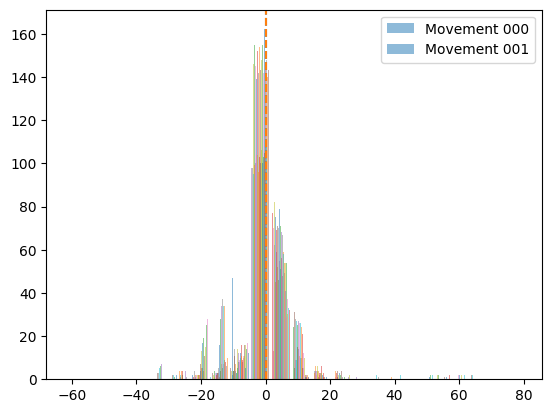

In [10]:
mov_a, mov_b = "000", "001"

da = np.load(os.path.join(PROCESSED_DIR, f"{mov_a}_2.npy"), allow_pickle=True)[:, :, 0]
db = np.load(os.path.join(PROCESSED_DIR, f"{mov_b}_2.npy"), allow_pickle=True)[:, :, 0]

plt.hist(da, bins=20, alpha=0.5, label=f"Movement {mov_a}", density=False)
plt.hist(db, bins=20, alpha=0.5, label=f"Movement {mov_b}", density=False)
plt.axvline(da.mean(), color="C0", linestyle="--")
plt.axvline(db.mean(), color="C1", linestyle="--")
plt.legend(); plt.show()

Prueba con diferentes canales y actividades y comenta si los histogramas pueden utilizarse para diferenciar entre diferentes actividades.